# Finding and evaluating high-scoring edges

**Input:** two author IOI clean/corrupted prompt pairs. **Model:** GPT-2 small. **Tools:** EAP and original input-embedding EAP-IG on the explicit native GPT-2 residual-message graph, followed by actual full-complement edge interventions.

**Run mode:** the default cells replay real completed model measurements from `snapshots/`, using the public library visualization API. Saved outputs are retained. Set `RERUN = True` only after installing the model dependencies and configuring the optional run below. These examples are demonstrations, not dataset-level reproductions.

In [1]:
from pathlib import Path
import sys, json, os
ROOT = next(parent for parent in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
            if (parent / "demos" / "common.py").is_file() and (parent / "pyproject.toml").is_file())
sys.path[:0] = [str(ROOT), str(ROOT / "src")]
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, HTML, display
from vlm_probing import Prober
from vlm_probing.visualization import (plot_input, plot_lens_heatmap, plot_attention_comparison,
                                       plot_causal_heatmap, plot_intervention_curves)
from demos.common import ASSETS, load_snapshot, load_image, show_figure, gqa_input, target_ranks
RERUN = False  # Keep False for the bundled, genuinely measured offline results.
print("Offline replay of archived model measurements; no inference or training.")

Offline replay of archived model measurements; no inference or training.


In [2]:
record = load_snapshot("eap_ig/gpt2_ioi.json")
for i,pair in enumerate(record["pairs"]):
    display(Markdown(f"**Clean prompt:** {pair['clean_prompt']}\n\n**Corrupted prompt:** {pair['donor_prompt']}\n\n**Score:** {pair['positive_token'].strip()} minus {pair['negative_token'].strip()}\n\nClean margin: {record['baseline_margin'][i]:.3f}; corrupted margin: {record['corrupt_margin'][i]:.3f}."))
print("Explicit independently replaceable edges:",record["graph"]["edge_count"])

**Clean prompt:** When Amy and Laura got a snack at the house, Laura decided to give it to

**Corrupted prompt:** When Amy and Laura got a snack at the house, Nicholas decided to give it to

**Score:** Amy minus Laura

Clean margin: 2.383; corrupted margin: 1.352.

**Clean prompt:** Then, Danielle and Andrew had a lot of fun at the office. Andrew gave a computer to

**Corrupted prompt:** Then, Danielle and Andrew had a lot of fun at the office. Jeremy gave a computer to

**Score:** Danielle minus Andrew

Clean margin: 6.164; corrupted margin: 3.214.

Explicit independently replaceable edges: 32491


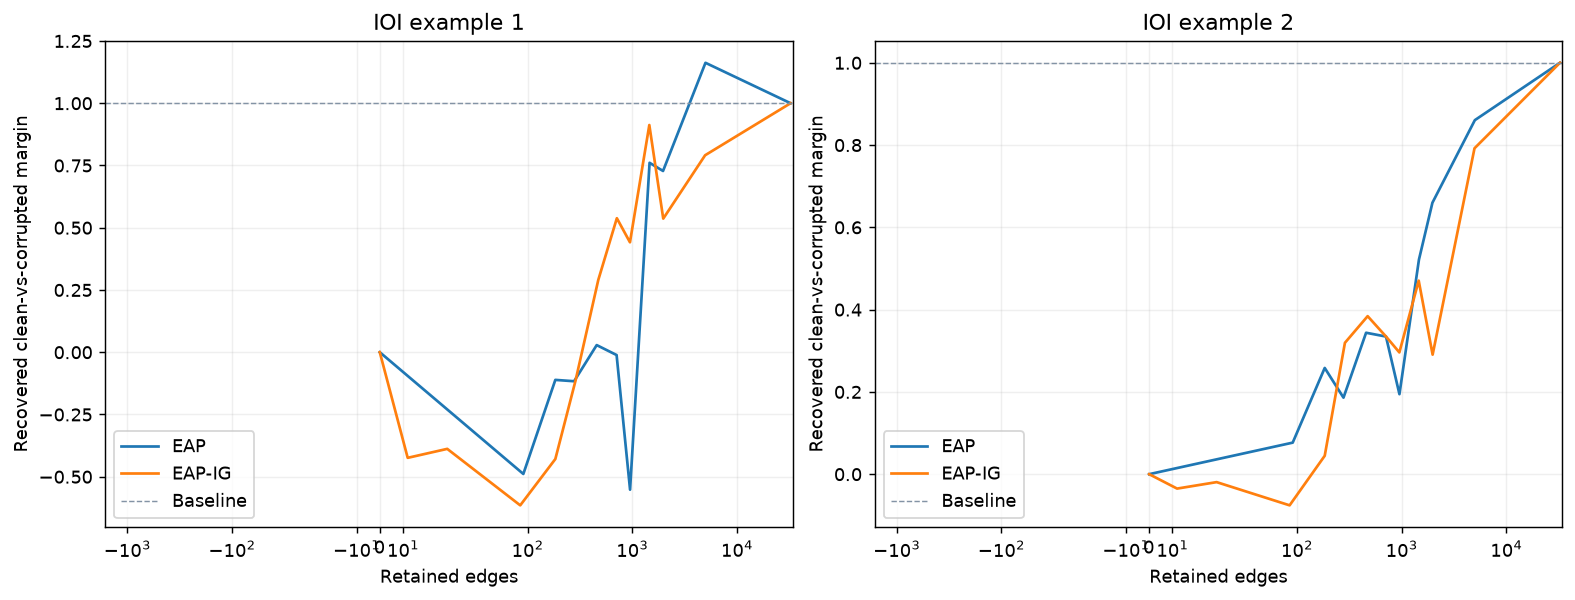

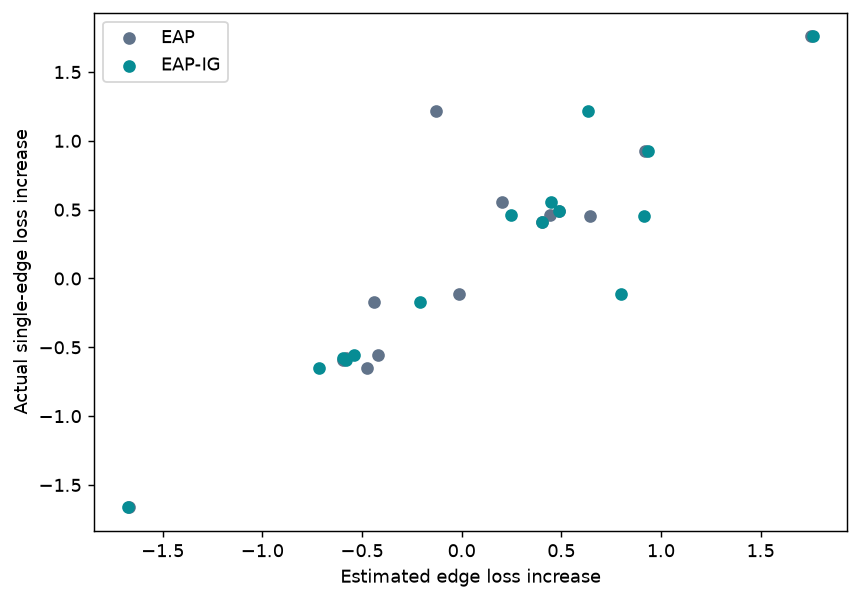

In [3]:
fig, axes = plt.subplots(1,len(record["pairs"]), figsize=(12,4.5), constrained_layout=True)
for i,(ax,pair) in enumerate(zip(axes,record["pairs"])):
    curves = {name.upper().replace("_","-"):{"x":series["retained_edges"],
              "y":np.asarray(series["faithfulness"])[:,i]} for name,series in record["curves"].items()}
    plot_intervention_curves(curves, ax=ax, baseline=1, xlabel="Retained edges",
                              ylabel="Recovered clean-vs-corrupted margin", title=f"IOI example {i+1}")
    ax.set_xscale("symlog",linthresh=50)
show_figure(fig)
# Actual single-edge replacements validate scores; this is not a causal circuit graph.
fig, ax = plt.subplots(figsize=(6.5,4.5),constrained_layout=True)
for method,color in [("eap_score","#61738a"),("ig_score","#078c94")]:
    ax.scatter([edge[method] for edge in record["exact_edges"]],
               [edge["measured_loss_increase"] for edge in record["exact_edges"]],
               label="EAP" if method=="eap_score" else "EAP-IG",color=color)
ax.set_xlabel("Estimated edge loss increase");ax.set_ylabel("Actual single-edge loss increase");ax.legend()
show_figure(fig)

**Selected connections:** edge widths show absolute estimated contribution; color shows its sign. Nodes are explicit computational components, not inferred functional head classes. These are estimated edges, while the recovery curve below uses fresh measured interventions.

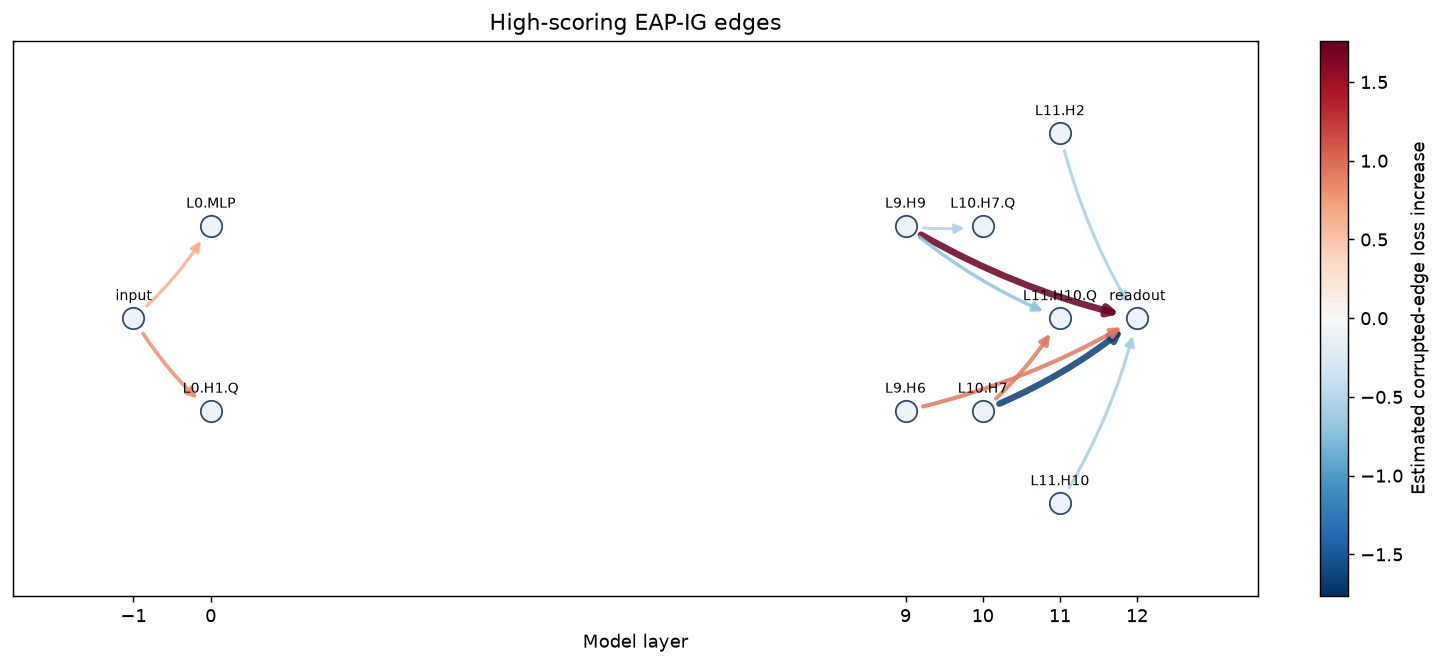

In [4]:
from vlm_probing.visualization import plot_connections
edges = [(edge["source"], edge["destination"], edge["ig_score"]) for edge in record["top_edges"][:12]]
nodes = {name for source,receiver,_ in edges for name in (source,receiver)}
def graph_layer(name):
    if name == "input":
        return -1
    if name == "readout":
        return record["graph"]["layers"]
    return int(name.split(".")[0][1:])
ax = plot_connections(edges,node_layers={node:graph_layer(node) for node in nodes},top_k=10,
                      title="High-scoring EAP-IG edges",value_label="Estimated corrupted-edge loss increase")
show_figure(ax.figure)

**How to read:** recovery 1 is the clean margin and 0 is the corrupted margin; values can be below 0 or above 1. Every retained-edge point is a fresh forward where all excluded edges are replaced by corrupted source messages. EAP-IG estimates edge scores along a linear input-embedding path; it is not node activation patching or endpoint message-space IG. Selection and evaluation use the same two display samples, so these are not dataset-level faithfulness rankings.

## Optional new model run

This cell is deliberately opt-in. `VLM_PROBING_MODEL` selects a Hugging Face model ID or local checkpoint; `VLM_PROBING_DEVICE` selects the device. Hugging Face uses its normal cache (`HF_HOME` can relocate it). Rerunning performs fresh forwards and may need a GPU. An architecture-specific input adapter may be needed when changing the model; inspect `probe.describe()` first.

In [5]:
if RERUN:
    from demos.runtime import bind_model
    from demos.ioi_inputs import prepare_pairs
    probe, tokenizer, device = bind_model("openai-community/gpt2")
    clean, corrupted, metric = prepare_pairs(record["pairs"],tokenizer,device)
    method = probe.causal.eap_ig(graph="transformer",steps=5,quadrature="left")
    attribution = method.run(clean,donor=corrupted,metric=metric)
    evaluation = method.evaluate(clean,donor=corrupted,metric=metric,attribution=attribution,
                                 budgets=[0,100,500,2000,len(method.graph.edge_names)])
    print("Actual evaluation tensors:",list(evaluation.tensors))
    print("High-scoring edges:")
    values = attribution.tensors["edge_scores"].abs()
    for index in values.topk(10).indices.tolist():
        print(attribution.metadata["edge_names"][index])
else:
    print("Fresh graph attribution and circuit evaluation skipped.")

Fresh graph attribution and circuit evaluation skipped.


## Sources and interpretation

**Paper:** [Have Faith in Faithfulness](https://arxiv.org/abs/2403.17806), Section 3; faithfulness Sections 4.2–4.3 / Figure 3; Appendix E–F. **Author code:** [EAP-IG](https://github.com/hannamw/EAP-IG). **Data:** [author IOI CSV](https://github.com/hannamw/eap-ig-faithfulness/tree/main/data/ioi), rows 826 and 475, with published corruption. Five left-rule input-integration steps follow the released author code; the paper writes a right-rule sum. This demo is text-only. Other architectures require explicit compatible edge graphs; no VLM graph is invented.

Bundled image and data attribution is listed in [README.md](README.md) and [image notices](assets/images/SOURCE_NOTICES.md). Model checkpoints and fitted lens artifacts are not included.